#### Land Class Interactions: Deciduous Woodland (DW) Gross Gain Sankey Diagram
- Will show percentage of Deciduous Woodland (DW) contributed from other land classes
- Relative to 2024 Area of DW

In [1]:
# Importing the required packages
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Importing localised file directory
project_root = Path(os.environ['marsh_tit_project'])

# Importing the required datsets
lcc = pd.read_csv(project_root/'ukceh'/'custom'/'lcg_england_wales_25m_grouped_labelled.csv')

#### Cleaning the imported DataFrame
- Filtering Land Change Classification (lcc) DataFrame to extract records of DW in the 'Classification' column (ie the 2024 column).
- Converting area units from m^2 to km^2.

In [ ]:
# Filtering to DW records
lcc_b_gain = (
    lcc[lcc['Classification']=='deciduous']
)

# Area conversion
lcc_b_gain['area'] = lcc_b_gain['Area [metre^2]']/(1000*1000)

# Removing redundant columns
lcc_b_gain = lcc_b_gain.drop(columns=['Area [metre^2]', 'PixelSum', 'RasterValue'])

#### Creating the Sankey Diagram

In [3]:
# Computing the total 2024 DW area - all percentages will be relative to this.
b_latest = sum(lcc_b_gain['area'])

In [4]:
# Defining the Sankey Diagram Nodes (8 in total: 1 DW in 1990, 1 DW in 2024, 6 other classes)

d_ = round((lcc_b_gain.iloc[0,2]/b_latest)*100,1) # DW 1990
c_d = round((lcc_b_gain.iloc[1,2]/b_latest)*100,1) # coniferous
a_d = round((lcc_b_gain.iloc[2,2]/b_latest)*100,1) # arable
g_d = round((lcc_b_gain.iloc[3,2]/b_latest)*100,1) # grassland
f_d = round((lcc_b_gain.iloc[4,2]/b_latest)*100,1) # freshwater
bua_d = round((lcc_b_gain.iloc[5,2]/b_latest)*100,1) # built-up areas
o_d = round((lcc_b_gain.iloc[6,2]/b_latest)*100,1) # other
_d = round((b_latest/b_latest)*100,1) # DW 2024


In [5]:
# Defining colour of nodes and links so they match Land classification map colours

# where '0.4' is the transparency
color_link = ['rgba(0,255,0,0.4)', # light green / DW
              'rgba(0,87,38,0.4)', # dark green / coniferous
              'rgba(254,255,0,0.4)', # yellow / arable
              'rgba(172,207,132,0.4)', # brown-green / grassland
              'rgba(77,163,239,0.4)', # blue / freshwater
              'rgba(222,19,43,0.4)', # red / built-up areas
              'rgba(0,0,0,0.4)'] # black / other

# where '0.9 is the transparency'
color_node = ['rgba(0,255,0,0.9)', # light green / DW
              'rgba(0,87,38,0.9)', # dark green / coniferous
              'rgba(254,255,0,0.9)', # yellow / arable
              'rgba(172,207,132,0.9)', # brown-green / grassland
              'rgba(77,163,239,0.9)', # blue / freshwater
              'rgba(222,19,43,0.9)', # red / built-up areas
              'rgba(0,0,0,0.9)', # red / built-up areas
             'rgba(0,255,0,0.9)'] # light green / DW

#### Defining the Positions of the Labels, Nodes and Links

In [6]:
# Importing Sankey Plot package
import plotly.graph_objects as go

# Adding Node labels
label=[f'Deciduous Woodland<br>{d_}%',
       f'Coniferous<br>{c_d}%',
       f'Arable<br>{a_d}%', 
       f'Grassland<br>{g_d}%', 
       f'Freshwater<br>{f_d}%', 
       f'Built-up areas<br>{bua_d}%', 
       f'Other<br>{o_d}%',
      f'Deciduous Woodland<br>{_d}%']

source=[0,1,2,3,4,5,6] # start node (match position of labels)
target=[7,7,7,7,7,7,7] # end node (match position of labels)
value=[d_, c_d, a_d, g_d, f_d, bua_d, o_d] # links
       

link = dict(source=source, 
            target=target, 
            value=value, 
            color=color_link)

node=dict(label=label, 
          pad=35, # adjusts spacing between links
          thickness=5, # adjusts node width
          color=color_node, 
          line=dict(width=0.1))

data=go.Sankey(link=link, node=node)

#### Plotting the Figure

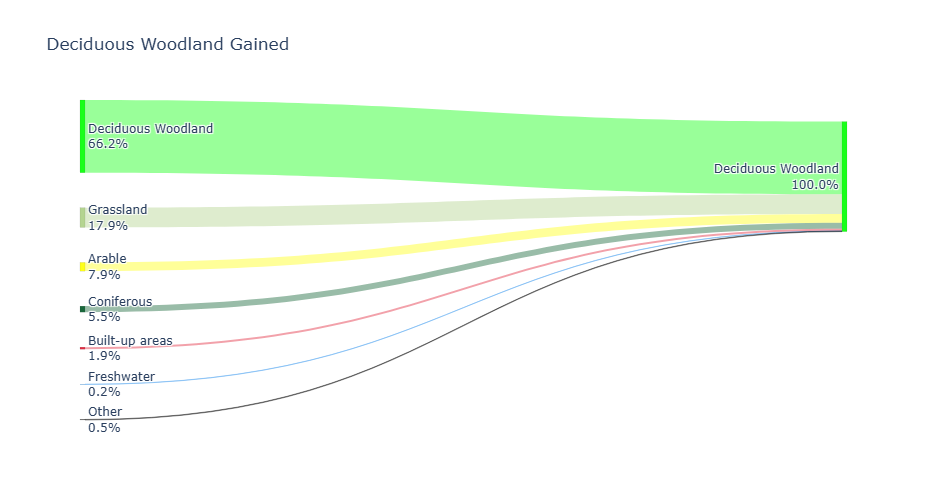

In [7]:
fig = go.Figure(data)
fig.update_layout(
    hovermode='x',
    title='Deciduous Woodland Gained',
    width=600, # width of figure
    height=500 # height of figure
)

# Exporting figure
fig.write_image(project_root/'gis_marsh_tit'/'project_pics'/'sankey_gain.png', 
                scale=2) # multiplies image pixels by 2 (for higher quality, increase). 
fig.show()